In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("All libraries loaded successfully! ✅")

All libraries loaded successfully! ✅


In [3]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
import os
os.listdir('/content/')

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']

In [5]:
# Load the dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Check the data
print("Shape of data:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
df.head()

Shape of data: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# TotalCharges has some empty strings - fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing values
df.dropna(inplace=True)

# Convert SeniorCitizen from 0/1 to Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Check shape after cleaning
print("\nShape after cleaning:", df.shape)
print("\nData cleaning done! ✅")

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Shape after cleaning: (7032, 21)

Data cleaning done! ✅


In [7]:
# Calculate KPIs
total_customers = len(df)
churned = len(df[df['Churn'] == 'Yes'])
retained = len(df[df['Churn'] == 'No'])
churn_rate = (churned / total_customers) * 100
retention_rate = (retained / total_customers) * 100

print("=" * 45)
print("       CUSTOMER CHURN KPI SUMMARY")
print("=" * 45)
print(f"Total Customers    : {total_customers}")
print(f"Churned Customers  : {churned}")
print(f"Retained Customers : {retained}")
print(f"Churn Rate         : {churn_rate:.2f}%")
print(f"Retention Rate     : {retention_rate:.2f}%")
print(f"Avg Monthly Charges: ${df['MonthlyCharges'].mean():.2f}")
print(f"Avg Tenure         : {df['tenure'].mean():.1f} months")
print("=" * 45)

       CUSTOMER CHURN KPI SUMMARY
Total Customers    : 7032
Churned Customers  : 1869
Retained Customers : 5163
Churn Rate         : 26.58%
Retention Rate     : 73.42%
Avg Monthly Charges: $64.80
Avg Tenure         : 32.4 months


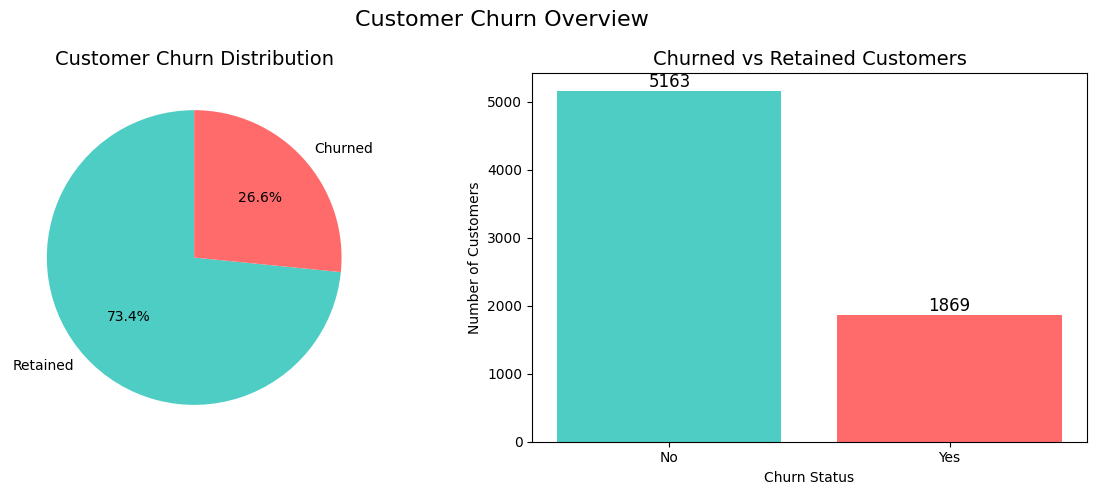

Chart 1 done! ✅


In [8]:
# Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie Chart
axes[0].pie(df['Churn'].value_counts(),
            labels=['Retained', 'Churned'],
            autopct='%1.1f%%',
            colors=['#4ECDC4', '#FF6B6B'],
            startangle=90)
axes[0].set_title('Customer Churn Distribution', fontsize=14)

# Bar Chart
churn_counts = df['Churn'].value_counts()
axes[1].bar(churn_counts.index, churn_counts.values,
            color=['#4ECDC4', '#FF6B6B'])
axes[1].set_title('Churned vs Retained Customers', fontsize=14)
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=12)

plt.suptitle('Customer Churn Overview', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 1 done! ✅")

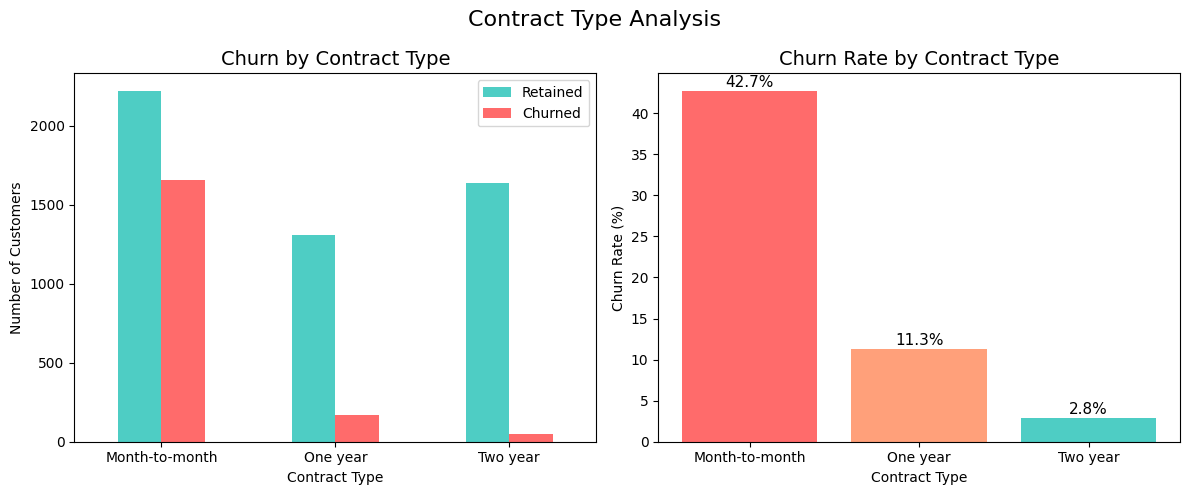

Chart 2 done! ✅


In [10]:
# Churn by Contract Type
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
contract_churn.plot(kind='bar', ax=axes[0],
                    color=['#4ECDC4', '#FF6B6B'],
                    rot=0)
axes[0].set_title('Churn by Contract Type', fontsize=14)
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(['Retained', 'Churned'])

# Churn Rate by Contract
churn_rate_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100)
axes[1].bar(churn_rate_contract.index,
            churn_rate_contract.values,
            color=['#FF6B6B', '#FFA07A', '#4ECDC4'])
axes[1].set_title('Churn Rate by Contract Type', fontsize=14)
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(churn_rate_contract.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Contract Type Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 2 done! ✅")

/tmp/ipykernel_10795/991824100.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby(['Tenure Group', 'Churn']).size().unstack()
/tmp/ipykernel_10795/991824100.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate_tenure = df.groupby('Tenure Group')['Churn'].apply(


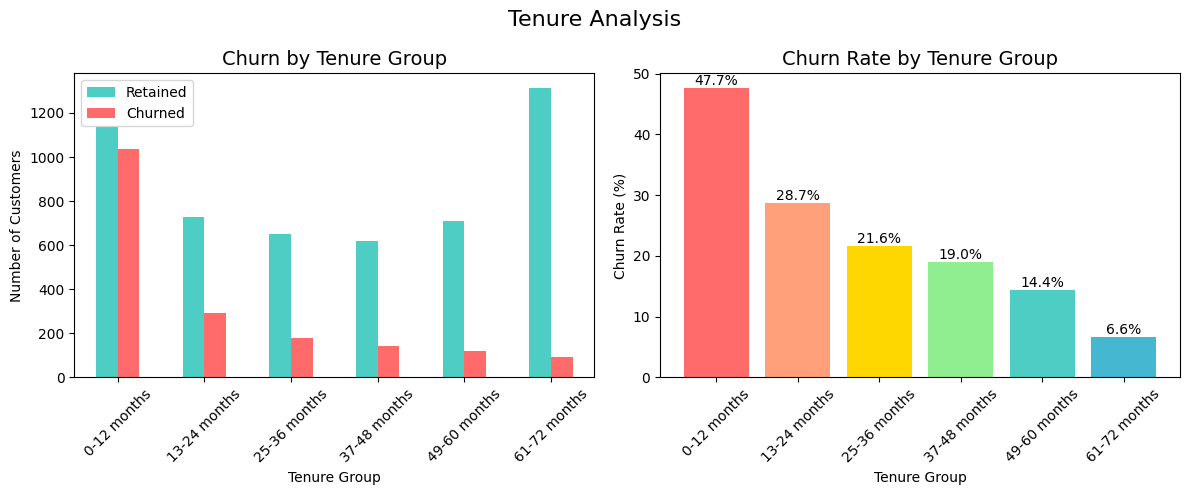

Chart 3 done! ✅


In [11]:
# Churn by Tenure Groups
df['Tenure Group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 36, 48, 60, 72],
                             labels=['0-12 months', '13-24 months',
                                     '25-36 months', '37-48 months',
                                     '49-60 months', '61-72 months'])

tenure_churn = df.groupby(['Tenure Group', 'Churn']).size().unstack()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
tenure_churn.plot(kind='bar', ax=axes[0],
                  color=['#4ECDC4', '#FF6B6B'],
                  rot=45)
axes[0].set_title('Churn by Tenure Group', fontsize=14)
axes[0].set_xlabel('Tenure Group')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(['Retained', 'Churned'])

# Churn Rate by Tenure
churn_rate_tenure = df.groupby('Tenure Group')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100)
axes[1].bar(churn_rate_tenure.index,
            churn_rate_tenure.values,
            color=['#FF6B6B','#FFA07A','#FFD700',
                   '#90EE90','#4ECDC4','#45B7D1'])
axes[1].set_title('Churn Rate by Tenure Group', fontsize=14)
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(churn_rate_tenure.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Tenure Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 3 done! ✅")

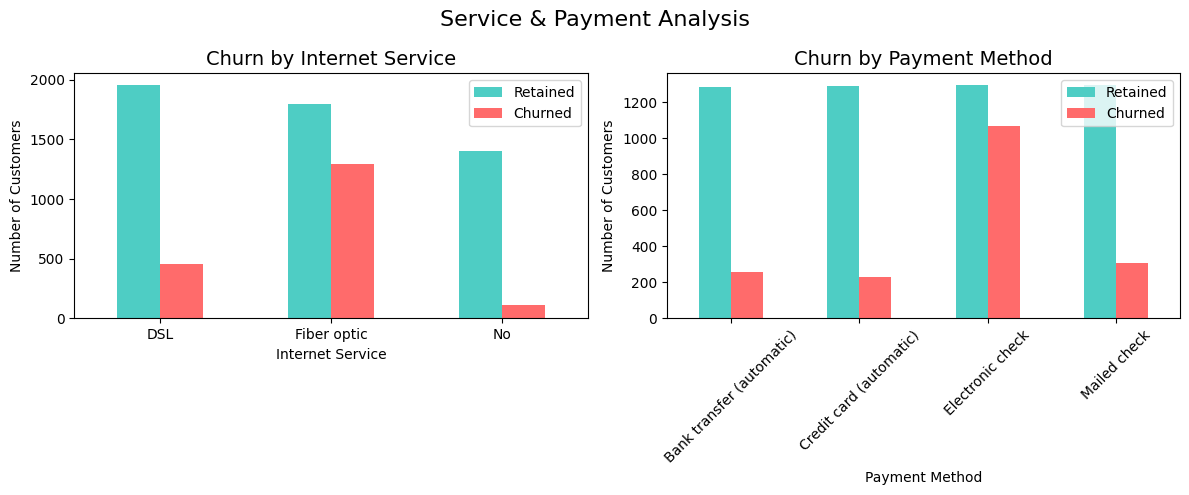

Chart 4 done! ✅


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn by Internet Service
internet_churn = df.groupby(['InternetService', 'Churn']).size().unstack()
internet_churn.plot(kind='bar', ax=axes[0],
                    color=['#4ECDC4', '#FF6B6B'],
                    rot=0)
axes[0].set_title('Churn by Internet Service', fontsize=14)
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(['Retained', 'Churned'])

# Churn by Payment Method
payment_churn = df.groupby(['PaymentMethod', 'Churn']).size().unstack()
payment_churn.plot(kind='bar', ax=axes[1],
                   color=['#4ECDC4', '#FF6B6B'],
                   rot=45)
axes[1].set_title('Churn by Payment Method', fontsize=14)
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(['Retained', 'Churned'])

plt.suptitle('Service & Payment Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 4 done! ✅")

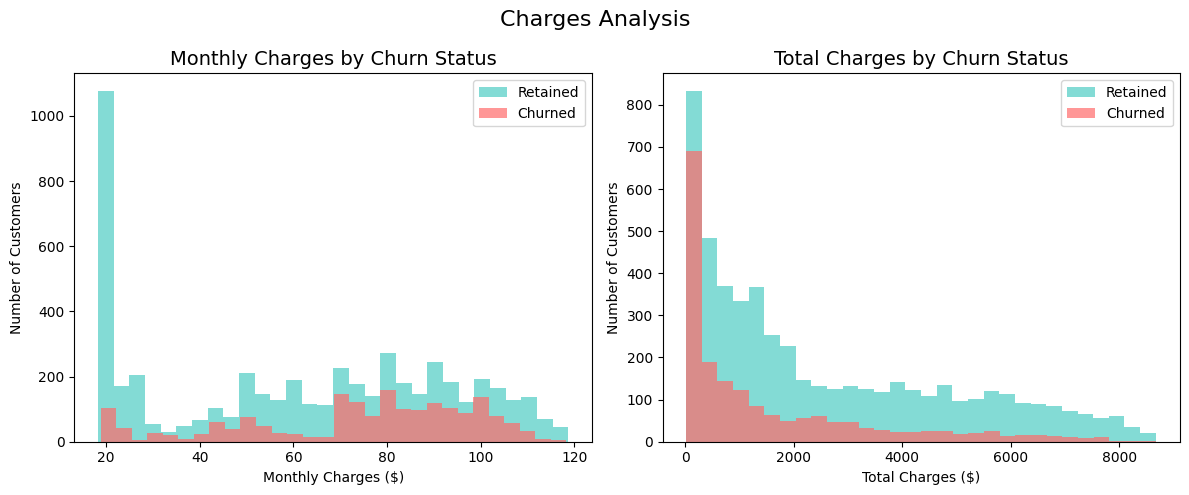

Chart 5 done! ✅


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Monthly Charges Distribution by Churn
axes[0].hist(df[df['Churn'] == 'No']['MonthlyCharges'],
             bins=30, alpha=0.7, color='#4ECDC4', label='Retained')
axes[0].hist(df[df['Churn'] == 'Yes']['MonthlyCharges'],
             bins=30, alpha=0.7, color='#FF6B6B', label='Churned')
axes[0].set_title('Monthly Charges by Churn Status', fontsize=14)
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Total Charges Distribution by Churn
axes[1].hist(df[df['Churn'] == 'No']['TotalCharges'],
             bins=30, alpha=0.7, color='#4ECDC4', label='Retained')
axes[1].hist(df[df['Churn'] == 'Yes']['TotalCharges'],
             bins=30, alpha=0.7, color='#FF6B6B', label='Churned')
axes[1].set_title('Total Charges by Churn Status', fontsize=14)
axes[1].set_xlabel('Total Charges ($)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.suptitle('Charges Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 5 done! ✅")

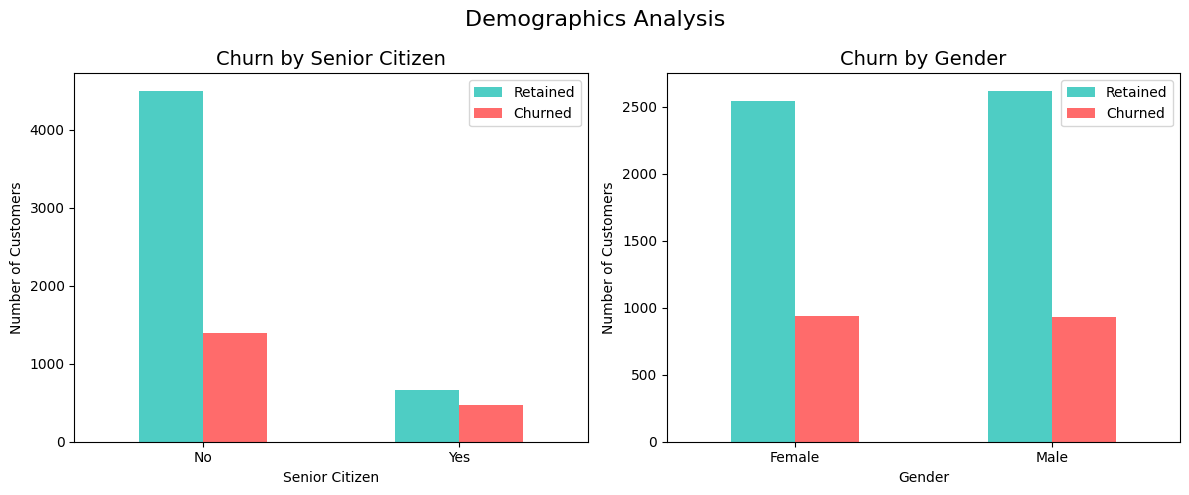

Chart 6 done! ✅


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn by Senior Citizen
senior_churn = df.groupby(['SeniorCitizen', 'Churn']).size().unstack()
senior_churn.plot(kind='bar', ax=axes[0],
                  color=['#4ECDC4', '#FF6B6B'],
                  rot=0)
axes[0].set_title('Churn by Senior Citizen', fontsize=14)
axes[0].set_xlabel('Senior Citizen')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(['Retained', 'Churned'])

# Churn by Gender
gender_churn = df.groupby(['gender', 'Churn']).size().unstack()
gender_churn.plot(kind='bar', ax=axes[1],
                  color=['#4ECDC4', '#FF6B6B'],
                  rot=0)
axes[1].set_title('Churn by Gender', fontsize=14)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(['Retained', 'Churned'])

plt.suptitle('Demographics Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 6 done! ✅")

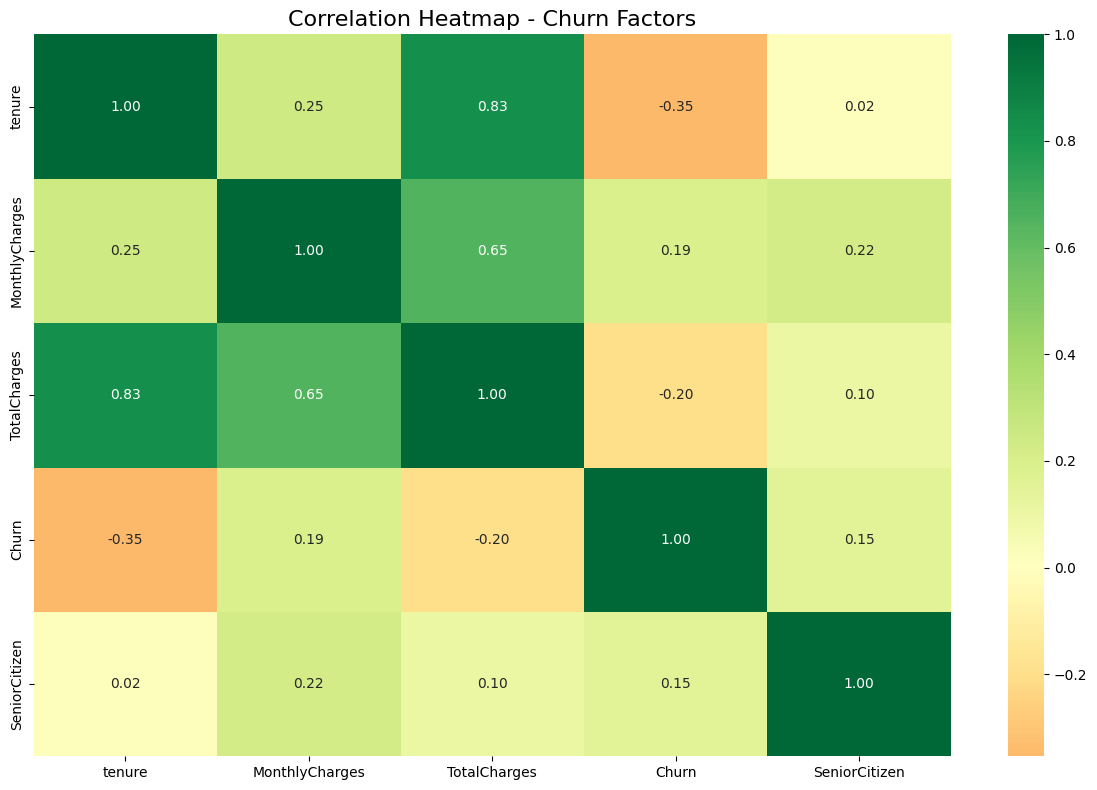

Chart 7 done! ✅


In [15]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Select numeric columns
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)
numeric_df['SeniorCitizen'] = (df['SeniorCitizen'] == 'Yes').astype(int)

corr = numeric_df.corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            ax=ax)

ax.set_title('Correlation Heatmap - Churn Factors', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 7 done! ✅")

In [16]:
print("=" * 50)
print("      CUSTOMER CHURN INSIGHTS & FINDINGS")
print("=" * 50)

# Churn by Contract
best_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).idxmin()
worst_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).idxmax()
print(f"\n✅ Lowest Churn Contract  : {best_contract}")
print(f"❌ Highest Churn Contract : {worst_contract}")

# Churn by Tenure
print(f"\n✅ Avg Tenure (Retained)  : {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"❌ Avg Tenure (Churned)   : {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")

# Churn by Charges
print(f"\n✅ Avg Monthly (Retained) : ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print(f"❌ Avg Monthly (Churned)  : ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")

# Churn by Internet Service
best_internet = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).idxmin()
worst_internet = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).idxmax()
print(f"\n✅ Lowest Churn Internet  : {best_internet}")
print(f"❌ Highest Churn Internet : {worst_internet}")

# Senior Citizens
senior_churn = (df[df['SeniorCitizen']=='Yes']['Churn']=='Yes').mean()*100
non_senior_churn = (df[df['SeniorCitizen']=='No']['Churn']=='Yes').mean()*100
print(f"\n❌ Senior Citizen Churn Rate    : {senior_churn:.1f}%")
print(f"✅ Non Senior Citizen Churn Rate: {non_senior_churn:.1f}%")

print("\n" + "=" * 50)
print("Insights generated successfully! ✅")
print("=" * 50)

      CUSTOMER CHURN INSIGHTS & FINDINGS

✅ Lowest Churn Contract  : Two year
❌ Highest Churn Contract : Month-to-month

✅ Avg Tenure (Retained)  : 37.7 months
❌ Avg Tenure (Churned)   : 18.0 months

✅ Avg Monthly (Retained) : $61.31
❌ Avg Monthly (Churned)  : $74.44

✅ Lowest Churn Internet  : No
❌ Highest Churn Internet : Fiber optic

❌ Senior Citizen Churn Rate    : 41.7%
✅ Non Senior Citizen Churn Rate: 23.7%

Insights generated successfully! ✅


In [17]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('Customer_Churn_Analysis_Report.pdf') as pdf:

    # Page 1: Title Page
    fig = plt.figure(figsize=(12, 8))
    fig.patch.set_facecolor('#2C3E50')
    plt.text(0.5, 0.70, 'Customer Churn Analysis', ha='center',
             fontsize=30, color='white', fontweight='bold')
    plt.text(0.5, 0.55, 'Retention Analysis Report', ha='center',
             fontsize=20, color='#4ECDC4')
    plt.text(0.5, 0.42, 'Total Customers: 7,032', ha='center',
             fontsize=16, color='white')
    plt.text(0.5, 0.32, 'Churn Rate: 26.58%  |  Retention Rate: 73.42%', ha='center',
             fontsize=14, color='white')
    plt.text(0.5, 0.20, 'Prepared by: Induri Sai Chandu', ha='center',
             fontsize=12, color='#BDC3C7')
    plt.axis('off')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 2: Churn Distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].pie(df['Churn'].value_counts(),
                labels=['Retained', 'Churned'],
                autopct='%1.1f%%',
                colors=['#4ECDC4', '#FF6B6B'])
    axes[0].set_title('Churn Distribution', fontsize=14)
    churn_counts = df['Churn'].value_counts()
    axes[1].bar(churn_counts.index, churn_counts.values,
                color=['#4ECDC4', '#FF6B6B'])
    axes[1].set_title('Churned vs Retained', fontsize=14)
    for i, v in enumerate(churn_counts.values):
        axes[1].text(i, v + 50, str(v), ha='center', fontsize=12)
    plt.suptitle('Customer Churn Overview', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 3: Contract Analysis
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
    contract_churn.plot(kind='bar', ax=axes[0],
                        color=['#4ECDC4', '#FF6B6B'], rot=0)
    axes[0].set_title('Churn by Contract Type', fontsize=14)
    axes[0].legend(['Retained', 'Churned'])
    churn_rate_contract = df.groupby('Contract')['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100)
    axes[1].bar(churn_rate_contract.index, churn_rate_contract.values,
                color=['#FF6B6B', '#FFA07A', '#4ECDC4'])
    axes[1].set_title('Churn Rate by Contract', fontsize=14)
    for i, v in enumerate(churn_rate_contract.values):
        axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)
    plt.suptitle('Contract Type Analysis', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 4: Tenure Analysis
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    tenure_churn = df.groupby(['Tenure Group', 'Churn']).size().unstack()
    tenure_churn.plot(kind='bar', ax=axes[0],
                      color=['#4ECDC4', '#FF6B6B'], rot=45)
    axes[0].set_title('Churn by Tenure Group', fontsize=14)
    axes[0].legend(['Retained', 'Churned'])
    churn_rate_tenure = df.groupby('Tenure Group')['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100)
    axes[1].bar(churn_rate_tenure.index, churn_rate_tenure.values,
                color=['#FF6B6B','#FFA07A','#FFD700',
                       '#90EE90','#4ECDC4','#45B7D1'])
    axes[1].set_title('Churn Rate by Tenure', fontsize=14)
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(churn_rate_tenure.values):
        axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
    plt.suptitle('Tenure Analysis', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 5: Charges Analysis
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].hist(df[df['Churn']=='No']['MonthlyCharges'],
                 bins=30, alpha=0.7, color='#4ECDC4', label='Retained')
    axes[0].hist(df[df['Churn']=='Yes']['MonthlyCharges'],
                 bins=30, alpha=0.7, color='#FF6B6B', label='Churned')
    axes[0].set_title('Monthly Charges by Churn', fontsize=14)
    axes[0].legend()
    axes[1].hist(df[df['Churn']=='No']['TotalCharges'],
                 bins=30, alpha=0.7, color='#4ECDC4', label='Retained')
    axes[1].hist(df[df['Churn']=='Yes']['TotalCharges'],
                 bins=30, alpha=0.7, color='#FF6B6B', label='Churned')
    axes[1].set_title('Total Charges by Churn', fontsize=14)
    axes[1].legend()
    plt.suptitle('Charges Analysis', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 6: Demographics
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    senior_churn = df.groupby(['SeniorCitizen', 'Churn']).size().unstack()
    senior_churn.plot(kind='bar', ax=axes[0],
                      color=['#4ECDC4', '#FF6B6B'], rot=0)
    axes[0].set_title('Churn by Senior Citizen', fontsize=14)
    axes[0].legend(['Retained', 'Churned'])
    gender_churn = df.groupby(['gender', 'Churn']).size().unstack()
    gender_churn.plot(kind='bar', ax=axes[1],
                      color=['#4ECDC4', '#FF6B6B'], rot=0)
    axes[1].set_title('Churn by Gender', fontsize=14)
    axes[1].legend(['Retained', 'Churned'])
    plt.suptitle('Demographics Analysis', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 7: Recommendations
    fig = plt.figure(figsize=(12, 8))
    fig.patch.set_facecolor('#2C3E50')
    plt.text(0.5, 0.93, 'Key Insights & Recommendations', ha='center',
             fontsize=22, color='white', fontweight='bold')
    insights = [
        "- Month-to-month contracts have the highest churn rate",
        "- Churned customers have avg tenure of only 18 months",
        "- Churned customers pay higher monthly charges ($74.44)",
        "- Fiber optic internet service has highest churn rate",
        "- Senior citizens churn at 41.7% - needs attention",
        "- Offer discounts to convert month-to-month to annual contracts",
        "- Introduce loyalty rewards for customers after 12 months",
        "- Review Fiber optic pricing and service quality",
        "- Create special retention plans for senior citizens",
        "- Proactively reach out to high charge customers"
    ]
    for i, insight in enumerate(insights):
        plt.text(0.08, 0.82 - i*0.08, insight, fontsize=13, color='white')
    plt.axis('off')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

print("PDF Report generated successfully! ✅")

/tmp/ipykernel_10795/2664846835.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby(['Tenure Group', 'Churn']).size().unstack()
/tmp/ipykernel_10795/2664846835.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate_tenure = df.groupby('Tenure Group')['Churn'].apply(


PDF Report generated successfully! ✅


In [18]:
from google.colab import files
files.download('Customer_Churn_Analysis_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>